In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# Improve visuals
sns.set(style="whitegrid", font_scale=1.2)
plt.rcParams["figure.figsize"] = (12, 6)

In [6]:
file_path = "stock prices.csv"
df = pd.read_csv(file_path)

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB
None


In [8]:
print(df.isnull().sum())

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64


In [13]:
# CONVERT DATE COLUMN TO DATETIME
df['date'] = pd.to_datetime(df['date'])
print("\nConverted 'date' column to datetime format.")

# Let's analyze one stock (example: AAPL)
stock_df = df[df['symbol'] == 'AAPL'].copy()
stock_df.sort_values('date', inplace=True)

print("\nSelected Stock: AAPL")
display(stock_df.head())


Converted 'date' column to datetime format.

Selected Stock: AAPL


,symbol,date,open,high,low,close,volume
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
484,AAPL,2014-01-03,78.9799,79.0999,77.2042,77.2828,98303870
967,AAPL,2014-01-06,76.7785,78.1142,76.2285,77.7042,103359151
1450,AAPL,2014-01-07,77.7599,77.9942,76.8464,77.1481,79432766
1933,AAPL,2014-01-08,76.9728,77.9371,76.9556,77.6371,64686685


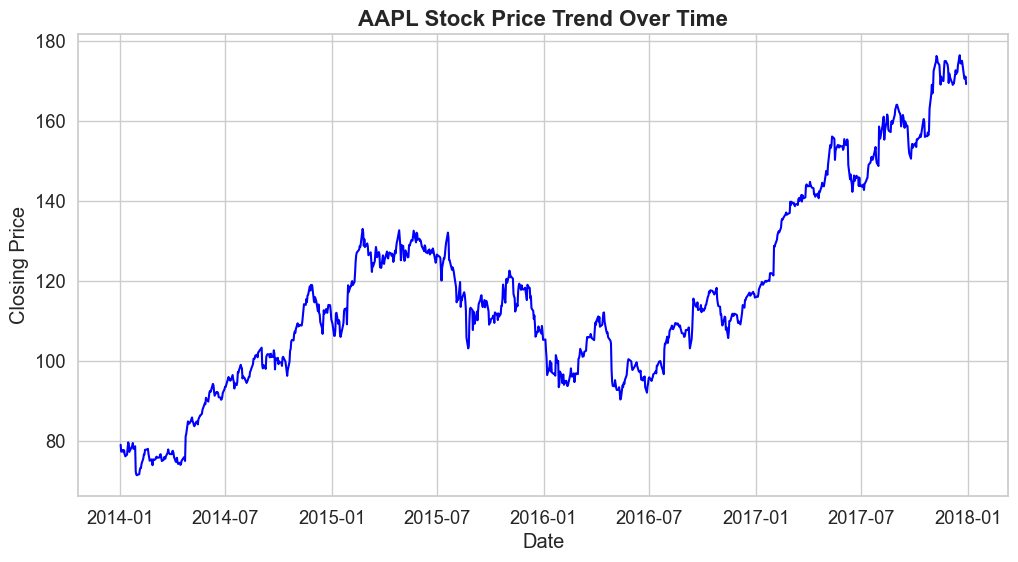

In [14]:
# VISUALIZE HISTORICAL STOCK PRICE TRENDS
plt.figure(figsize=(12,6))
plt.plot(stock_df['date'], stock_df['close'], color='blue')
plt.title("AAPL Stock Price Trend Over Time", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

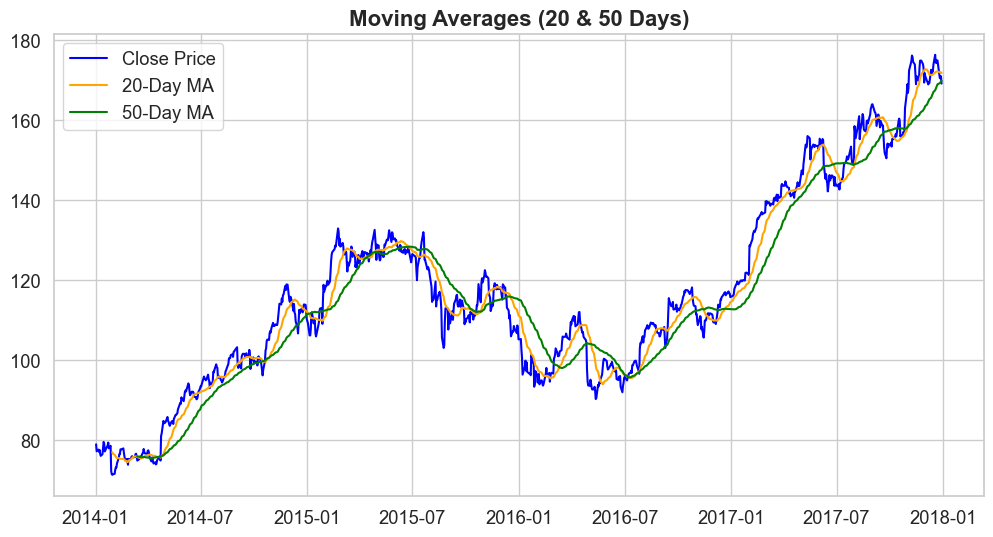

In [15]:
# MOVING AVERAGE (ROLLING MEAN)
stock_df['MA_20'] = stock_df['close'].rolling(window=20).mean()
stock_df['MA_50'] = stock_df['close'].rolling(window=50).mean()

plt.figure(figsize=(12,6))
plt.plot(stock_df['date'], stock_df['close'], label='Close Price', color='blue')
plt.plot(stock_df['date'], stock_df['MA_20'], label='20-Day MA', color='orange')
plt.plot(stock_df['date'], stock_df['MA_50'], label='50-Day MA', color='green')

plt.title("Moving Averages (20 & 50 Days)", fontsize=16, fontweight='bold')
plt.legend()
plt.show()

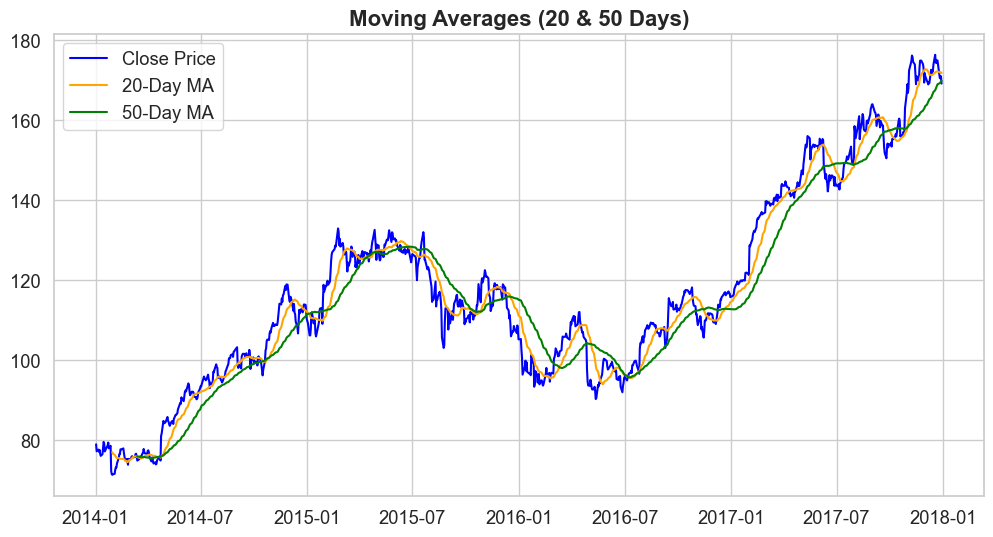

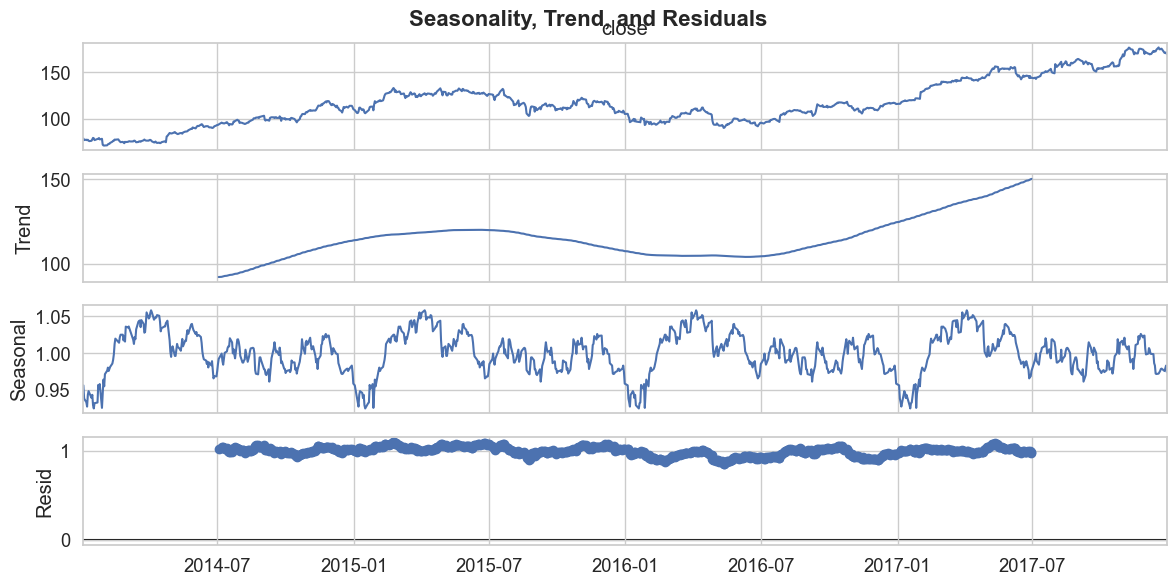

In [17]:
# SEASONALITY ANALYSIS
stock_df.set_index('date', inplace=True)
decomposition = seasonal_decompose(stock_df['close'], model='multiplicative', period=252)
decomposition.plot()
plt.suptitle("Seasonality, Trend, and Residuals", fontsize=16, fontweight='bold')
plt.show()

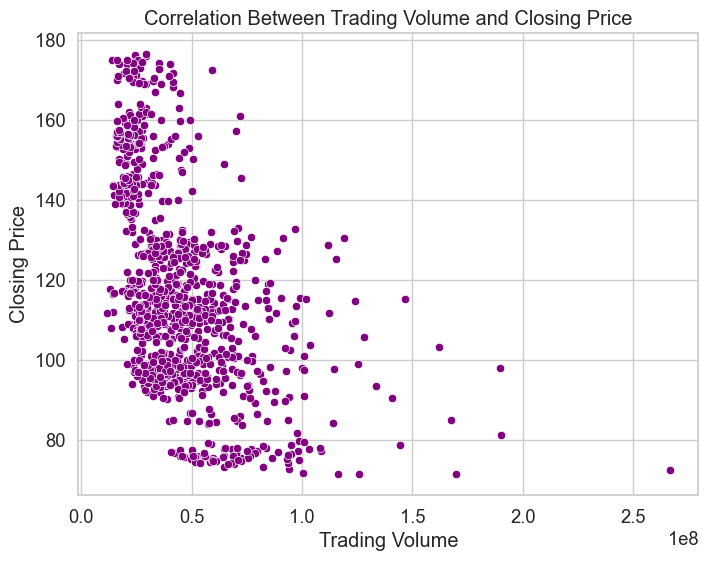


Correlation between Closing Price and Volume: -0.480


In [18]:
# CORRELATION ANALYSIS (PRICE VS VOLUME)
plt.figure(figsize=(8,6))
sns.scatterplot(data=stock_df, x='volume', y='close', color='purple')
plt.title("Correlation Between Trading Volume and Closing Price")
plt.xlabel("Trading Volume")
plt.ylabel("Closing Price")
plt.show()

corr = stock_df['close'].corr(stock_df['volume'])
print(f"\nCorrelation between Closing Price and Volume: {corr:.3f}")

In [19]:
# FORECASTING USING ARIMA MODEL
# Simple ARIMA forecast on closing prices
train = stock_df['close'][:-30]
test = stock_df['close'][-30:]

model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=30)

C:\Users\VAIBHAV ADMANE\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\VAIBHAV ADMANE\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\VAIBHAV ADMANE\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\VAIBHAV ADMANE\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. 

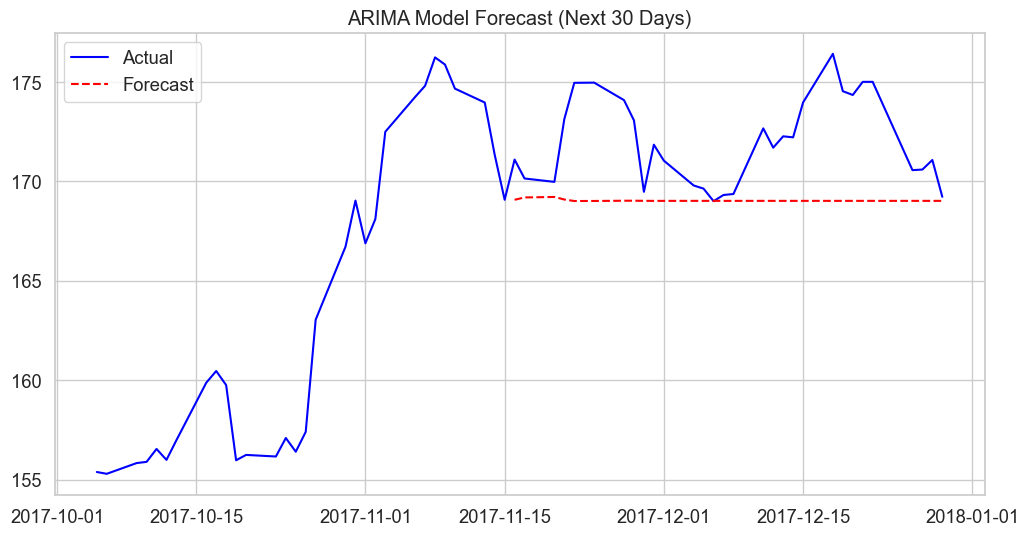

In [20]:
# VISUALIZE FORECAST
plt.figure(figsize=(12,6))
plt.plot(stock_df.index[-60:], stock_df['close'][-60:], label='Actual', color='blue')
plt.plot(test.index, forecast, label='Forecast', color='red', linestyle='--')
plt.title("ARIMA Model Forecast (Next 30 Days)")
plt.legend()
plt.show()